### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [222]:
data = pd.read_csv('data/coupons.csv')

In [223]:
pd.set_option('display.max_columns', None)
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [224]:
## Understand which columns have NULL Data 
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [225]:
# Understand which rows are duplicate
data.duplicated().sum()

np.int64(74)

3. Decide what to do about your missing data -- drop, replace, other...

In [226]:
## Drop the duplicate rows
data = data.drop_duplicates()

In [227]:
data.duplicated().sum()

np.int64(0)

In [228]:
## Drop car column as most values are null
data = data.drop(columns=['car'])

## Drop direction_opp column as it is redundant with direction_same column
data = data.drop(columns=['direction_opp'])

In [229]:
# For the behavior columns with missing values, calculate the mode and fill the missing values
# List of columns to impute and fill with mode
behavioral_cols = ['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar']

# Fill missing values with the most frequent value (mode) of each column
for col in behavioral_cols:
    col_mode = data[col].mode()[0]
    data[col] = data[col].fillna(col_mode)

In [230]:
data.sample(10)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,Y
2179,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,21,Single,0,Bachelors degree,Student,$100000 or More,4~8,gt8,4~8,gt8,1~3,1,1,0,0,1
1748,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,26,Single,0,Bachelors degree,Education&Training&Library,$25000 - $37499,never,1~3,less1,1~3,less1,1,1,0,0,1
7264,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,1d,Female,26,Married partner,0,Associates degree,Unemployed,$37500 - $49999,less1,1~3,1~3,1~3,1~3,1,0,0,0,1
1910,Home,Alone,Sunny,55,6PM,Bar,1d,Male,31,Single,0,Bachelors degree,Unemployed,Less than $12500,less1,1~3,gt8,1~3,never,1,0,0,1,0
12683,Work,Alone,Sunny,80,7AM,Restaurant(20-50),2h,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1,0,0,1,0
11844,Work,Alone,Sunny,80,7AM,Restaurant(20-50),2h,Female,50plus,Widowed,1,Associates degree,Healthcare Support,$12500 - $24999,less1,less1,4~8,1~3,less1,1,0,0,1,0
4264,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),1d,Female,26,Single,0,Bachelors degree,Education&Training&Library,$50000 - $62499,1~3,never,4~8,1~3,less1,1,1,0,0,1
9904,No Urgent Place,Alone,Snowy,30,2PM,Bar,1d,Male,21,Unmarried partner,0,Some college - no degree,Student,$12500 - $24999,never,less1,gt8,4~8,1~3,1,0,0,0,0
1148,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,31,Married partner,0,Some college - no degree,Computer & Mathematical,$100000 or More,less1,less1,gt8,4~8,less1,1,1,0,0,0
11192,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,0,Bachelors degree,Student,$12500 - $24999,less1,gt8,gt8,gt8,less1,1,1,0,0,1


4. What proportion of the total observations chose to accept the coupon?



In [231]:
## Number of rows with acceptance
accepted = (data['Y'] == 1).sum()

## Number of total rows, and compute percentage of accepted vs all rows
proportion = (accepted / len(data))*100
print(proportion)

56.75654242664552


5. Use a bar plot to visualize the `coupon` column.

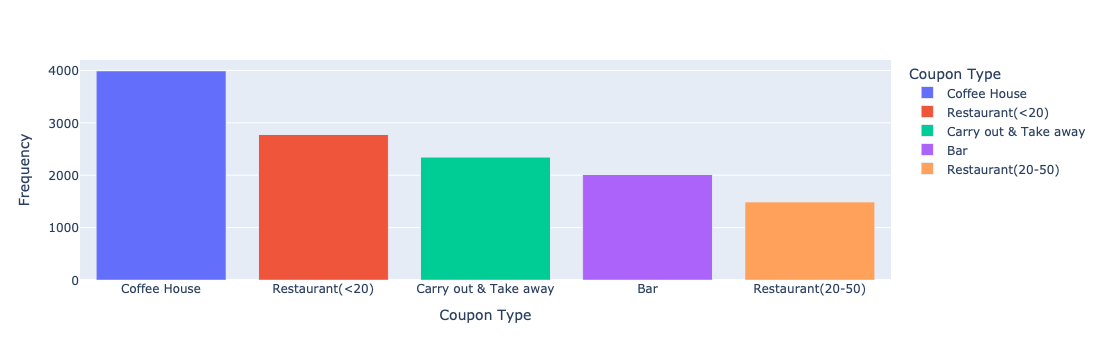

In [232]:
import plotly.express as px

# Calculate the frequency of each coupon type
coupon_counts = data['coupon'].value_counts().reset_index()
coupon_counts.columns = ['Coupon Type', 'Frequency']

fig = px.bar(coupon_counts, x = 'Coupon Type', y = 'Frequency', color='Coupon Type')
fig.show()


6. Use a histogram to visualize the temperature column.

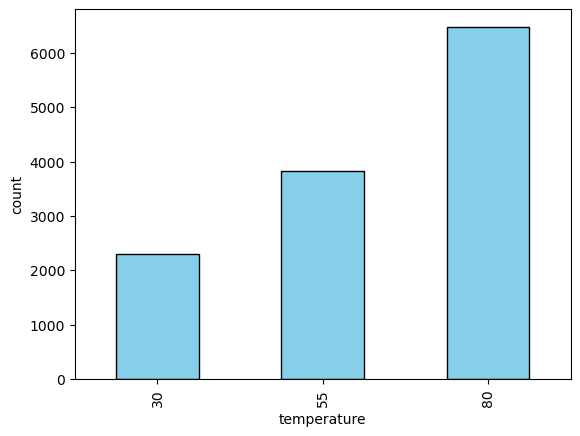

In [233]:
# Plotting the histogram
data['temperature'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel('count')

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [234]:
# Create a new data frame for coupon type "Bar"
bar_coupons = data.query('coupon == "Bar"')
bar_coupons.sample(10)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,Y
10280,No Urgent Place,Alone,Snowy,30,2PM,Bar,1d,Female,50plus,Single,1,Bachelors degree,Legal,$25000 - $37499,never,less1,4~8,1~3,less1,1,0,0,0,0
8876,No Urgent Place,Alone,Snowy,30,2PM,Bar,1d,Male,26,Single,0,Graduate degree (Masters or Doctorate),Healthcare Support,$37500 - $49999,4~8,1~3,4~8,1~3,less1,1,0,0,0,1
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,1~3,4~8,1~3,1,0,0,1,1
4205,No Urgent Place,Partner,Sunny,80,6PM,Bar,2h,Male,41,Married partner,0,Graduate degree (Masters or Doctorate),Computer & Mathematical,$37500 - $49999,less1,less1,gt8,gt8,4~8,1,1,0,0,1
11257,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,31,Single,0,Some college - no degree,Transportation & Material Moving,$50000 - $62499,1~3,4~8,4~8,4~8,1~3,1,1,0,0,1
2097,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Female,26,Single,0,Bachelors degree,Unemployed,Less than $12500,4~8,1~3,gt8,4~8,1~3,1,0,0,0,1
9168,No Urgent Place,Alone,Snowy,30,2PM,Bar,1d,Male,31,Single,0,Bachelors degree,Office & Administrative Support,$25000 - $37499,never,less1,less1,less1,less1,1,0,0,0,0
105,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,0,Associates degree,Student,$12500 - $24999,1~3,less1,1~3,less1,1~3,1,1,1,0,0
7395,No Urgent Place,Kid(s),Snowy,30,6PM,Bar,1d,Male,46,Married partner,1,Graduate degree (Masters or Doctorate),Management,$87500 - $99999,less1,1~3,1~3,less1,1~3,1,1,0,0,0
7679,Home,Alone,Sunny,80,6PM,Bar,2h,Male,36,Single,0,Some college - no degree,Construction & Extraction,$50000 - $62499,never,never,1~3,less1,less1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [235]:
## Find the ratio of acceptance of bar copons versus the number of rows (all bar coupons)

print((bar_coupons['Y'] == 1).sum() / len(bar_coupons))

0.4099502487562189


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [236]:
# The unique values in this dataset are: 'never', 'less1', '1~3', '4~8', 'gt8'
three_or_fewer = ['never', 'less1', '1~3']
more_than_three = ['4~8', 'gt8']

# Calculate the acceptance rate (mean of column 'Y') for 3 or fewer visits
rate_three_or_fewer = bar_coupons[bar_coupons['Bar'].isin(three_or_fewer)]['Y'].mean()

# Calculate the acceptance rate (mean of column 'Y') for more than 3 visits
rate_more_than_three = bar_coupons[bar_coupons['Bar'].isin(more_than_three)]['Y'].mean()

# Output the calculated comparison rates
print(f"Acceptance rate for 3 or fewer bar visits/month: {rate_three_or_fewer:.2%}")
print(f"Acceptance rate for more than 3 bar visits/month: {rate_more_than_three:.2%}")

Acceptance rate for 3 or fewer bar visits/month: 37.05%
Acceptance rate for more than 3 bar visits/month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [237]:
# Create a copy of the data frame where coupon is Bar type
bar_coupons_copy = data[data['coupon'] == 'Bar'].copy()

# Replace '50plus' with 50 (or any number you prefer)
bar_coupons_copy['age'] = bar_coupons_copy['age'].replace('50plus', 50)

# Clean the '50plus' and 'below21' string to a numeric value (using 50 and 20 respectively as a representative value
bar_coupons_copy.loc[:, 'age'] = bar_coupons_copy['age'].replace('50plus', 50)
bar_coupons_copy.loc[:, 'age'] = bar_coupons_copy['age'].replace('below21', 20)

# Convert the column with text values to numeric safely
bar_coupons_copy.loc[:, 'age'] = pd.to_numeric(bar_coupons_copy['age'])

# Define frequent bar visits based on standard dataset categories
# (In this dataset, '1~3', '4~8', and 'gt8' are the categories for bar visits)
frequent_bars = ["1~3", "4~8", "gt8"]

# Define the boolean condition for the specific target group
# Drivers over 25 who visit a bar more than once a month
target_condition = (bar_coupons_copy["Bar"].isin(frequent_bars)) & (bar_coupons_copy["age"] > 25)

# 3. Separate the dataset into the target group and everyone else
group_target = bar_coupons_copy[target_condition]
group_all_others = bar_coupons_copy[~target_condition]

# 4. Calculate acceptance rates using the mean of the 'Y' column
# (Multiplying by 100 converts the proportion to a percentage)
rate_target = group_target["Y"].mean() * 100
rate_others = group_all_others["Y"].mean() * 100

# 5. Output the final comparison results
print(f"Target Group Acceptance Rate: {rate_target:.2f}%")
print(f"All Others Acceptance Rate:   {rate_others:.2f}%")


Target Group Acceptance Rate: 69.52%
All Others Acceptance Rate:   33.46%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [238]:
# Define the criteria based on dataset categories
frequent_bars = ["1~3", "4~8", "gt8"]
excluded_occupations = ["Farming Fishing & Forestry"]

# Define the boolean condition for the target group
target_condition = (
    (bar_coupons_copy["Bar"].isin(frequent_bars))
    & (bar_coupons_copy["passanger"] != "Kid(s)")
    & (~bar_coupons_copy["occupation"].isin(excluded_occupations))
)

# Separate the dataset into the target group and everyone else
group_target = bar_coupons_copy[target_condition]
group_all_others = bar_coupons_copy[~target_condition]

# Calculate acceptance rates using the mean of the 'Y' column
rate_target = group_target["Y"].mean() * 100
rate_others = group_all_others["Y"].mean() * 100

# Output the final comparison results
print(f"Target Group Acceptance Rate: {rate_target:.2f}%")
print(f"All Others Acceptance Rate:   {rate_others:.2f}%")

Target Group Acceptance Rate: 71.32%
All Others Acceptance Rate:   29.54%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [239]:
# Define standard category filters based on the dataset
frequent_bars = ["1~3", "4~8", "gt8"]
frequent_cheap_restaurants = ["4~8", "gt8"]
low_income = [
    "Less rather than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999",
]

# Define the three individual conditions
cond_1 = (
    bar_coupons_copy["Bar"].isin(frequent_bars)
    & (bar_coupons_copy["passanger"] != "Kid(s)")
    & (bar_coupons_copy["maritalStatus"] != "Widowed")
)

cond_2 = bar_coupons_copy["Bar"].isin(frequent_bars) & (bar_coupons_copy["age"] < 30)

cond_3 = bar_coupons_copy["RestaurantLessThan20"].isin(frequent_cheap_restaurants) & (
    bar_coupons_copy["income"].isin(low_income)
)

# Calculate acceptance rate for first condition
group_target = bar_coupons_copy[cond_1]
rate_target = group_target["Y"].mean() * 100
rate_others = group_all_others["Y"].mean() * 100

print(f"go to bars more than once a month, had passengers that were not a kid, and were not widowed: {rate_target:.2f}%")

# Calculate acceptance rate for second condition
group_target = bar_coupons_copy[cond_2]
rate_target = group_target["Y"].mean() * 100
rate_others = group_all_others["Y"].mean() * 100

print(f"go to bars more than once a month and are under the age of 30 : {rate_target:.2f}%")

# Calculate acceptance rate for third condition
group_target = bar_coupons_copy[cond_3]
rate_target = group_target["Y"].mean() * 100
rate_others = group_all_others["Y"].mean() * 100

print(f"go to cheap restaurants more than 4 times a month and income is less than 50K: {rate_target:.2f}%")

# Now Combine the conditions using the logical OR operator (|)
target_condition = cond_1 | cond_2 | cond_3

# Separate the dataset into the combined target group and all others
group_target = bar_coupons_copy[target_condition]
group_all_others = bar_coupons_copy[~target_condition]

# Calculate acceptance rates
rate_target = group_target["Y"].mean() * 100
rate_others = group_all_others["Y"].mean() * 100

# 6. Output the final comparison results
print(f"Combined Target Group Acceptance Rate: {rate_target:.2f}%")
print(f"All Others Acceptance Rate:            {rate_others:.2f}%")



go to bars more than once a month, had passengers that were not a kid, and were not widowed: 71.32%
go to bars more than once a month and are under the age of 30 : 72.17%
go to cheap restaurants more than 4 times a month and income is less than 50K: 45.76%
Combined Target Group Acceptance Rate: 61.24%
All Others Acceptance Rate:            29.57%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

The experiments done above yield the following learnings:
1. The overall acceptance rate of bar coupons is ~40%.
2. The acceptance rate is highest in folks who are frequent bar visitors (at least thrice a month)
3. The acceptance rate goes higher when going with drivers who are without a kid or Occupation other than Farming & Fishing
4. The highest acceptance rate for bars is for those without kids and under the age of 30

These criteria provide valuable insight into the target audience to give bar coupons to the younger drivers who are driving without kids but extend them to the population who are more frequent bar visitors to cast a slightly wider net with the coupons. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

The goal of the below experiment is to understand the relative acceptance rate for each coupon type.

This helps understand which coupon type has the highest yield rate in terms of acceptance and helps targeted future campaigns to focus on the high yielding coupon types, and/ or modify the lower yielding coupon types to get to a higher acceptance rate.

In [240]:
# Create a series with total number of coupons per coupon type
coupon_counts = data['coupon'].value_counts()
print(coupon_counts)

coupon
Coffee House             3989
Restaurant(<20)          2779
Carry out & Take away    2344
Bar                      2010
Restaurant(20-50)        1488
Name: count, dtype: int64


In [241]:
coupon_counts.info()

<class 'pandas.core.series.Series'>
Index: 5 entries, Coffee House to Restaurant(20-50)
Series name: count
Non-Null Count  Dtype
--------------  -----
5 non-null      int64
dtypes: int64(1)
memory usage: 80.0+ bytes


In [242]:
# Find the acceptance rate for each coupon type
accepted_coupons = data.groupby('coupon')['Y'].sum()
print(accepted_coupons)

coupon
Bar                       824
Carry out & Take away    1720
Coffee House             1989
Restaurant(20-50)         657
Restaurant(<20)          1967
Name: Y, dtype: int64


In [243]:
acceptance_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   coupon  5 non-null      object 
 1   Y       5 non-null      float64
dtypes: float64(1), object(1)
memory usage: 212.0+ bytes


In [244]:
# Merge the DataFrame and Series together
result = acceptance_rate.merge(coupon_counts, left_on='coupon', right_index=True)

# Display the final acceptance rates
print(result[['coupon', 'Y']])

                  coupon         Y
0                    Bar  0.409950
1  Carry out & Take away  0.733788
2           Coffee House  0.498621
3      Restaurant(20-50)  0.441532
4        Restaurant(<20)  0.707809


In [245]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   coupon  5 non-null      object 
 1   Y       5 non-null      float64
 2   count   5 non-null      int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 252.0+ bytes


The above gives a summary of the copon being most accepted as Carry out & Take away followed closely by lower priced restaurant.

Bars had an overall lowest acceptance rate, with pricey restaurants being slightly higher.

Now let us use two plotting techniques that help visualize the number of coupons issued vs acceptance rate

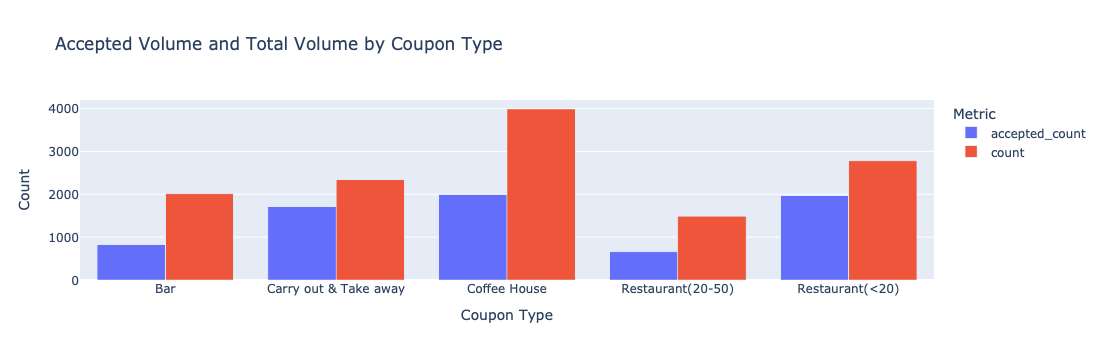

In [246]:
import plotly.express as px

# 1. Create a new column by multiplying the data of 'Y' and 'count'
result['accepted_count'] = result['Y'] * result['count']

# 2. Pass the new column name into Plotly list
fig = px.bar(
    result, 
    x='coupon', 
    y=['accepted_count', 'count'], 
    barmode='group',
    labels={'value': 'Count', 'coupon': 'Coupon Type', 'variable': 'Metric'},
    title='Accepted Volume and Total Volume by Coupon Type'
)

fig.show()

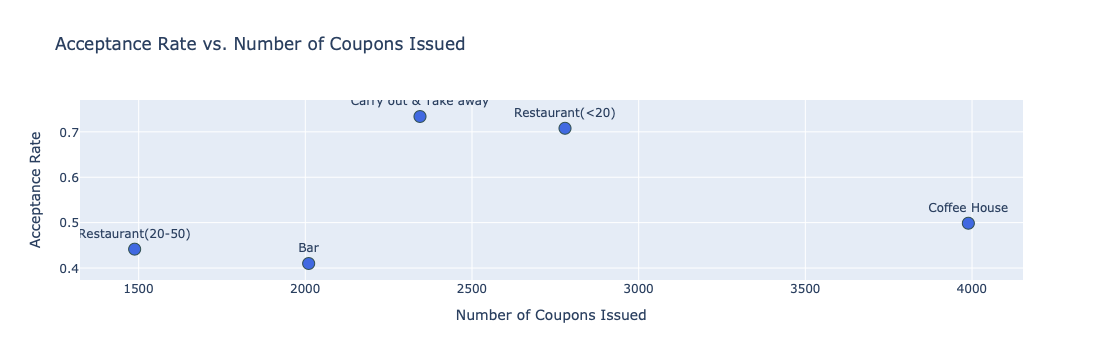

In [247]:
fig = px.scatter(
    result, 
    x='count', 
    y='Y', 
    text='coupon',
    labels={
        'count': 'Number of Coupons Issued', 
        'Y': 'Acceptance Rate'
    },
    title='Acceptance Rate vs. Number of Coupons Issued'
)

# Customize layout to position coupon labels cleanly above the points
fig.update_traces(
    textposition='top center', 
    marker=dict(size=12, color='royalblue', line=dict(width=1, color='DarkSlateGrey'))
)

# Display the interactive graph
fig.show()

The above visualizes certain interesting takeaways:
1. Coffee House has the most coupons issued but lower acceptance rate
2. Carry Out & Takeaway has half the coupons issued as coffee house, but a significantly higher acceptance rate
3. A clear takeaway is a higher opportunity for carry out and takeaway as well as lower priced restaurants to have higher coupons issued as they have the highest acceptance 